In [11]:
import matplotlib.pyplot as plt
from algorithms.tss_file import TSSFile
import os
from algorithms.wfm_edge import WFM_edge
from algorithms.tf_correction import get_fall_time

In [12]:
def find_file(filename, search_dir):
    for root, dirs, files in os.walk(search_dir):
        if filename in files:
            return root
    return None

In [ ]:
folder = r'Y:\TESTDATA\DP\2025\12'
tss_file1 = 'Tek20251210T103053.tss'
path1 = find_file(tss_file1, folder)
tss1 = TSSFile(path1, tss_file1, source='Local')

tss_file2 = 'Tek20251210T104158.tss'
path2 = find_file(tss_file2, folder)
tss2 = TSSFile(path1, tss_file2, source='Local')
channel_labels = tss1.channel_labels
num = len(channel_labels.keys())
print(channel_labels)

{'ch1': 'Vg_LS', 'ch2': 'Ids', 'ch3': 'Vds', 'ch4': 'Vcl'}


In [14]:
def get_time(time, vd, vg):
    vd_edges = WFM_edge(vd, time, falling_edge_number=2, 
                            rising_edge_number=2, 
                            peak_width=1,
                            peak_distance=10, 
                            sigma=100,
                            margin_ratio=20,)

    vg_edges = WFM_edge(vg, time, falling_edge_number=2, 
                            rising_edge_number=2, 
                            peak_width=1,
                            peak_distance=10, 
                            sigma=100,
                            margin_ratio=20,)

    time_thresh_1 = 10
    time_thresh_2 = 90
    vd_f1 = vd_edges.get_edge(2, 'falling', time_thresh_2)['time']
    edge = vd_edges.get_edge(2, 'falling', time_thresh_1)
    vd_f2_results = get_fall_time(vd, time, 25, edge, vd_edges)
    vd_f2 = vd_f2_results['time']

    vd_r1 = vd_edges.get_edge(1, 'rising', time_thresh_1)['time']
    vd_r2 = vd_edges.get_edge(1, 'rising', time_thresh_2)['time']
    vg_r1 = vg_edges.get_edge(2, 'rising', time_thresh_1)['time']
    vg_f1 = vg_edges.get_edge(1, 'falling', time_thresh_2)['time']

    return vd_f1, vd_f2, vd_r1, vd_r2, vg_r1, vg_f1

In [17]:
time1 = tss1.waveforms[list(channel_labels.keys())[0]].time_for_frame()*1e9
time2 = tss2.waveforms[list(channel_labels.keys())[0]].time_for_frame()*1e9

vd1 = tss1.waveforms['ch3'].values_for_frame(0)
vg1 = tss1.waveforms['ch1'].values_for_frame(0)
vd_f1a, vd_f2a, vd_r1a, vd_r2a, vg_r1a, vg_f1a = get_time(time1, vd1, vg1)

vd2 = tss2.waveforms['ch3'].values_for_frame(0)
vg2 = tss2.waveforms['ch1'].values_for_frame(0)
vd_f1b, vd_f2b, vd_r1b, vd_r2b, vg_r1b, vg_f1b = get_time(time2, vd2, vg2)

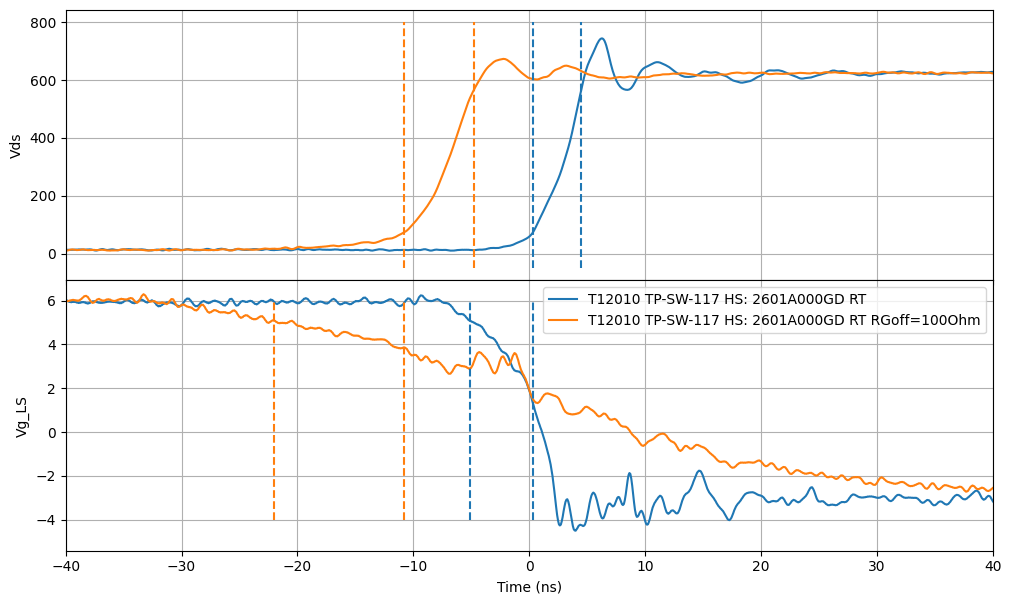

In [23]:
fig, axs = plt.subplots(2, 1, sharex=True, figsize=(10, 6))
# fig.suptitle(tss_file.split('.')[0])
fig.tight_layout()
fig.subplots_adjust(hspace=0)

axs[0].plot(time1, vd1, label='T12010 TP-SW-117 HS: 2601A000GD RT')
axs[0].plot(time2, vd2, label='T12010 TP-SW-117 HS: 2601A000GD RT RGoff=100Ohm')
axs[0].vlines(vd_r1a, -50, 800, linestyle='--', color='#1f77b4')
axs[0].vlines(vd_r2a, -50, 800, linestyle='--', color='#1f77b4')
axs[0].vlines(vd_r1b, -50, 800, linestyle='--', color='#ff7f0e')
axs[0].vlines(vd_r2b, -50, 800, linestyle='--', color='#ff7f0e')
axs[0].set_ylabel('Vds')
axs[0].grid(True)

axs[1].plot(time1, vg1, label='T12010 TP-SW-117 HS: 2601A000GD RT')
axs[1].plot(time2, vg2, label='T12010 TP-SW-117 HS: 2601A000GD RT RGoff=100Ohm')
axs[1].vlines(vd_r1a, -4, 6, linestyle='--', color='#1f77b4')
axs[1].vlines(vg_f1a, -4, 6, linestyle='--', color='#1f77b4')
axs[1].vlines(vd_r1b, -4, 6, linestyle='--', color='#ff7f0e')
axs[1].vlines(vg_f1b, -4, 6, linestyle='--', color='#ff7f0e')
axs[1].set_ylabel('Vg_LS')
axs[1].grid(True)

plt.legend()
plt.xlabel('Time (ns)')
plt.xlim([-40, 40])
#plt.legend(loc='best')
plt.show()